# 1. Cargar datos a Colab y Excel

Fuente: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales

El cargue de datos en excel se hace mediante el comando "xl". 🚀

In [1]:
import pandas as pd

df = pd.read_csv("/content/supermarket_sales.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Describir elementos de la tabla (estadísticos descriptivos)

🔍 ¡Vamos a explorar datos como unos cracks!

Veamos lo fácil e intuitivo que es crear estadísticos descriptivos usando Python 🐍 en Excel o en Colab.
Después, vamos a comparar cómo se hace esto mismo pero con el método tradicional de Excel 📊... ¡y tú decides con cuál te quedas! 💥

In [2]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


## 3. Conteo de registros por ciudad

In [5]:
df.groupby("City")['Invoice ID'].count()

,Invoice ID
City,
Mandalay,332
Naypyitaw,328
Yangon,340


## 4. Promedio de ventas por tipo de cliente

📚 ¿Qué cálculos podemos hacer con groupby()?
✅ .mean() → Promedio de ventas por tipo de cliente
✅ .sum() → Total de ventas acumuladas por tipo de cliente
✅ .count() → Cuántas compras hizo cada tipo de cliente
✅ .min() / .max() → Valor mínimo y máximo de compra por cliente
✅ .median() → Mediana (muy útil cuando hay valores extremos)
✅ .std() → Desviación estándar (qué tan variadas son las compras)

In [7]:
df.groupby("Customer type").agg(
    mean_total=('Total', 'mean'),
    sum_quantity=('Quantity', 'sum'),
    count_invoices=('Invoice ID', 'count'),
    min_rating=('Rating', 'min'),
    max_rating=('Rating', 'max')
)

,mean_total,sum_quantity,count_invoices,min_rating,max_rating
Customer type,,,,,
Member,327.791305,2785,501,4.0,10.0
Normal,318.122856,2725,499,4.0,10.0


In [9]:
df.groupby(['City', 'Customer type']).agg(
    mean_total=('Total', 'mean'),
    sum_quantity=('Quantity', 'sum'),
    count_invoices=('Invoice ID', 'count'),
    avg_rating=('Rating', 'mean')
)

mean_total  sum_quantity  count_invoices  avg_rating
City      Customer type                                                      
Mandalay  Member         325.482945           924             165    6.770303
          Normal         314.329257           896             167    6.865269
Naypyitaw Member         336.575636           897             169    7.048521
          Normal         337.656755           934             159    7.098742
Yangon    Member         321.182488           964             167    6.998802
          Normal         303.831763           895             173    7.054335

## 5. Promedio de calificación por línea de producto (ordenado desc)

🧠 Ordenar los datos para que hablen más claro
Después de agrupar y calcular estadísticas, no basta con tener los números…
👉 El orden hace la diferencia.
Con sort_values() podemos resaltar los grupos más importantes: los que más venden, los que menos califican, o los que tienen más transacciones.

In [13]:
df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)

,Rating
Product line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


## 6. Total de ventas por método de pago

In [14]:
df.groupby('Payment')['Total'].sum()

,Total
Payment,
Cash,112206.570
Credit card,100767.072
Ewallet,109993.107


## 7. Crear nueva columna: ingreso promedio por producto

🧠 Crear nuevas columnas en un DataFrame (sin tocar la tabla original de Excel)
Una de las ventajas más poderosas de trabajar con Python en Excel o Colab es que puedes crear nuevas columnas directamente desde código, sin alterar los datos originales en la hoja de cálculo.

In [15]:
df['ingreso_promedio_por_producto'] = df['Total'] / df['Quantity']
display(df.head())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,ingreso_promedio_por_producto
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,78.4245
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6,16.0440
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4,48.6465
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4,61.1310
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3,90.6255


## 8. Convertir la fecha y extraer mes

In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
display(df.head())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,ingreso_promedio_por_producto,Month
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,78.4245,1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,16.0440,3
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,48.6465,3
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,61.1310,1
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,90.6255,2


## 9. Ventas totales por mes

In [25]:
monthly_sales = df.groupby('Month')['Total'].sum()
display(monthly_sales)

,Total
Month,
1,116291.868
2,97219.374
3,109455.507


## 10. Histograma de calificaciones

📊 ¿Qué es un histograma?
Un histograma es un gráfico de barras especialmente diseñado para mostrar la distribución de una variable numérica continua.
En lugar de mostrar valores individuales, agrupa los datos en rangos (o "bins") y te muestra cuántos datos caen dentro de cada rango.

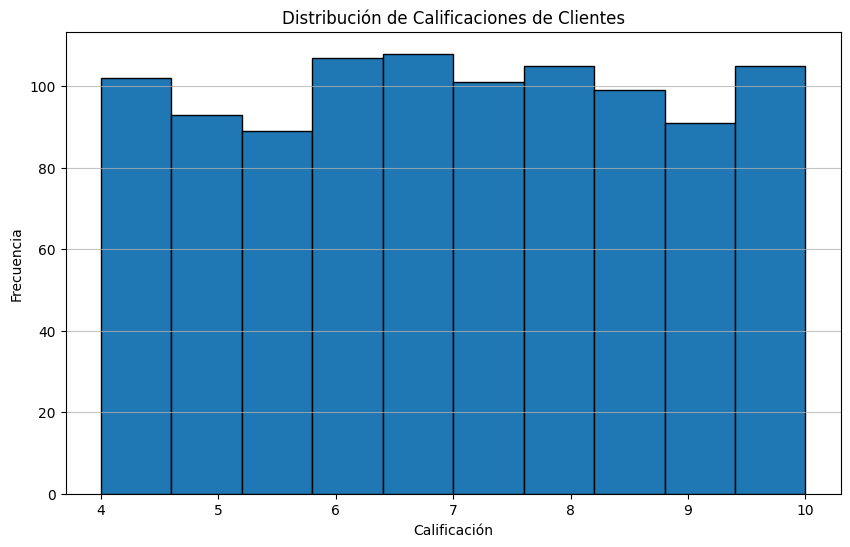

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Rating'], bins=10, edgecolor='black')
plt.title('Distribución de Calificaciones de Clientes')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 11. Gráfico de Ventas por ciudad

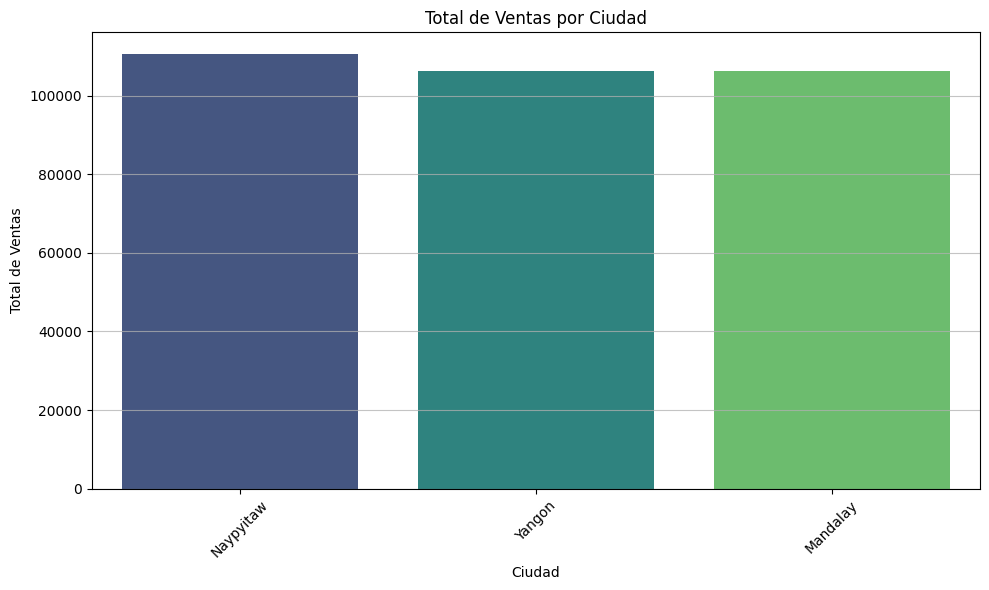

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_by_city = df.groupby('City')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_city.index, y=sales_by_city.values, hue=sales_by_city.index, palette='viridis', legend=False)
plt.title('Total de Ventas por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Total de Ventas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 12. Boxplot de ingresos por ciudad

📦 ¿Qué es un Boxplot (diagrama de caja)?
Un boxplot es una herramienta visual que resume la distribución de una variable numérica y resalta los valores atípicos (outliers).
Es uno de los gráficos más potentes para entender rápidamente cómo se comportan los datos. 👀

📐 ¿Qué muestra un boxplot?
Un solo gráfico te da mucha info:

Línea central → la mediana (percentil 50)

Caja → representa el 50% de los datos (del percentil 25 al 75)

Bigotes → valores que se encuentran dentro de un rango “aceptable”

Puntos sueltos → outliers (valores extremos)

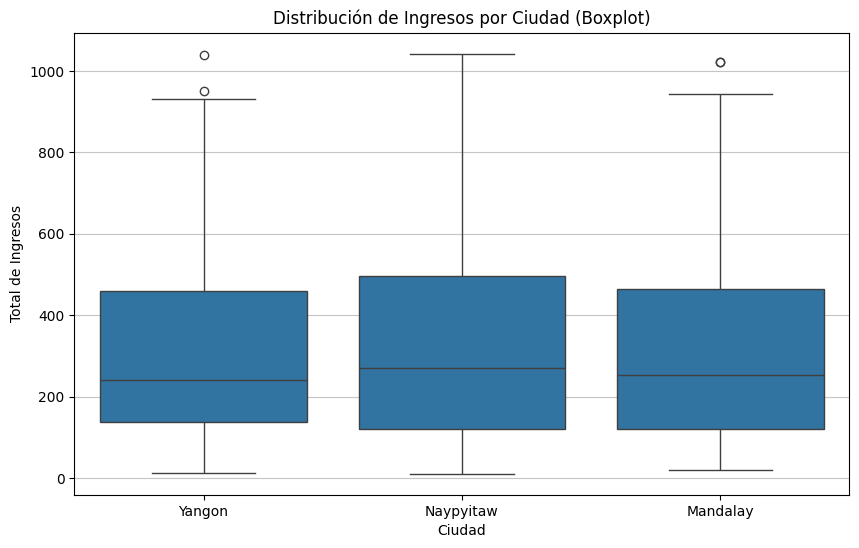

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='Total', data=df)
plt.title('Distribución de Ingresos por Ciudad (Boxplot)')
plt.xlabel('Ciudad')
plt.ylabel('Total de Ingresos')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 13. Mapa de calor de correlación

🌐 ¿Qué es un mapa de correlación?
Un mapa de correlación (o heatmap de correlación) muestra de forma visual qué tan relacionadas están entre sí las variables numéricas de un dataset.

Se basa en el cálculo del coeficiente de correlación (por defecto, Pearson), que mide la fuerza y dirección de la relación lineal entre dos variables.

🔢 ¿Cómo se interpreta?
El valor del coeficiente va de -1 a 1:

Valor	Significado
1	Correlación positiva perfecta ➕
0	Sin correlación 😐
-1	Correlación negativa perfecta ➖
🔍 ¿Qué nos permite ver un mapa de correlación?
✅ Si dos variables están muy relacionadas (y cuál depende de cuál)
✅ Si hay redundancia de información
✅ Si podríamos predecir una variable a partir de otra
✅ Si hay relaciones negativas que podrían ser útiles (ej: más descuento = menos ganancias)

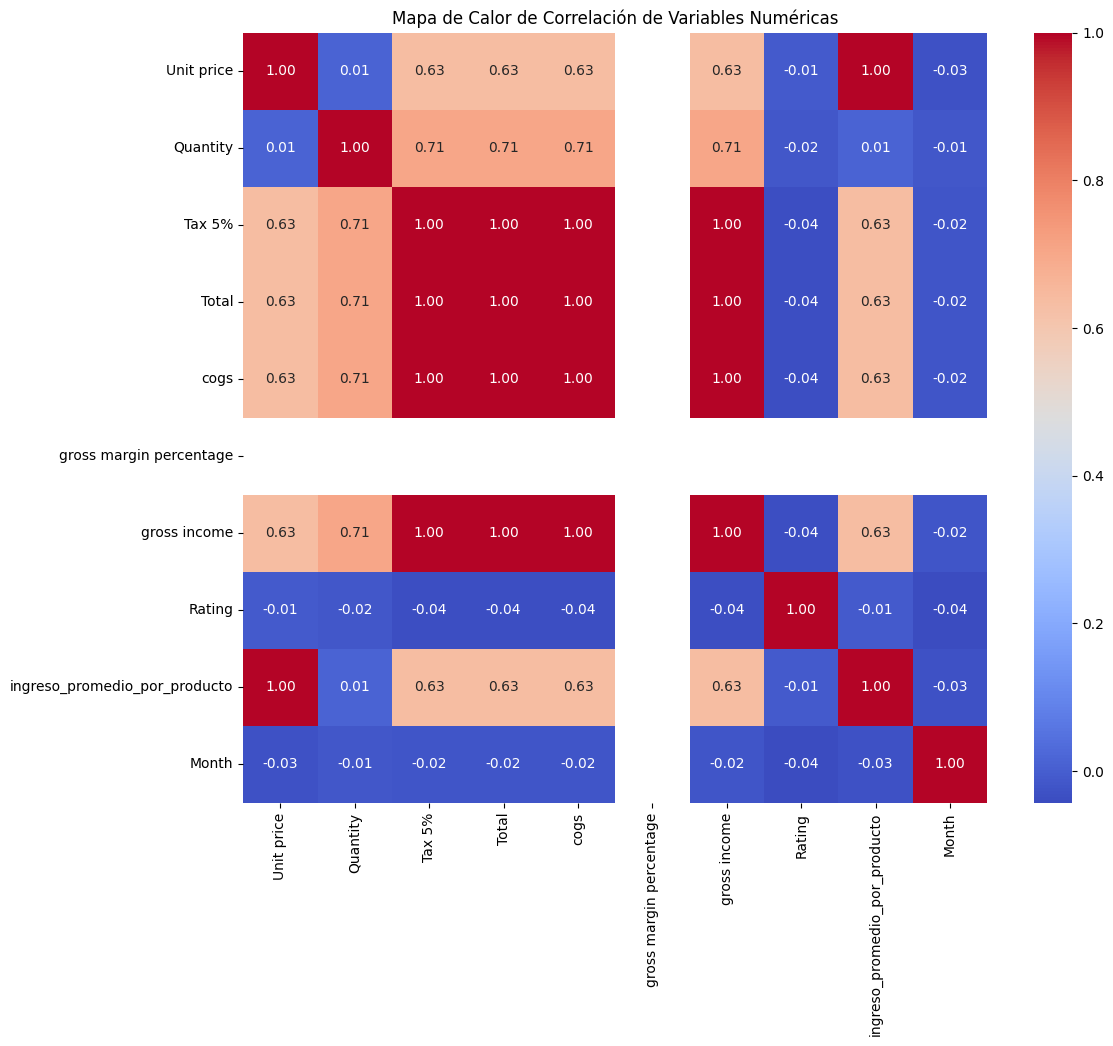

In [30]:
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación de Variables Numéricas')
plt.show()

## 14. Grafico de correlación entre cantidades y total

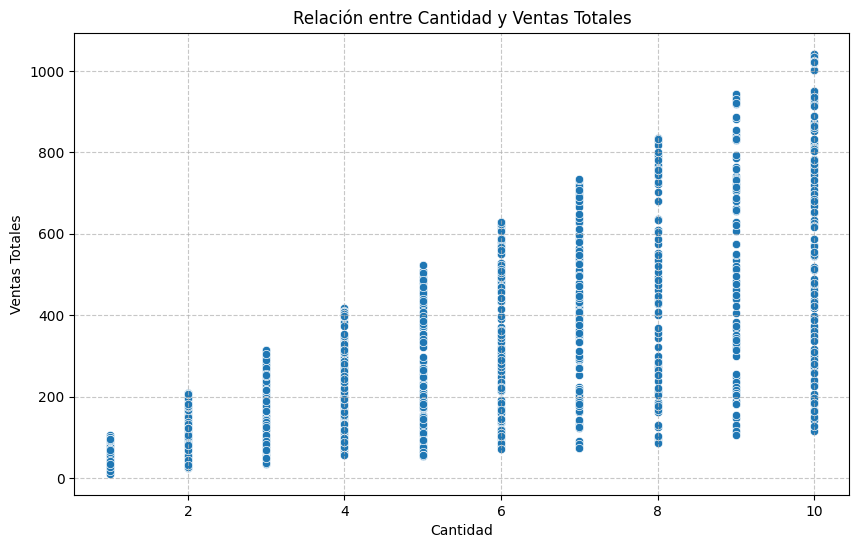

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Total', data=df)
plt.title('Relación entre Cantidad y Ventas Totales')
plt.xlabel('Cantidad')
plt.ylabel('Ventas Totales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 🤖💬 Preguntas poderosas con AI

✅ Estructura de un buen prompt para usar conmigo (ChatGPT o cualquier IA):
Contexto del dataset: qué datos tengo, columnas importantes, tipo de archivo

Objetivo claro: qué quiero saber, descubrir o visualizar

Formato de respuesta deseado: tabla, código, gráfico, etc. (opcional)

💬 Ejemplos de buenos prompts para que ellos usen contigo desde cero:

❓ Prompt 1: Análisis simple por grupo

"Tengo un dataset de ventas de supermercado, con columnas como City, Gender, Total, Customer type y Product line.
¿Me puedes ayudar a calcular el promedio de ventas por tipo de cliente (Customer type) usando Python en Excel o Colab?"

❓ Prompt 2: Visualización de distribución

"Estoy analizando una columna llamada Rating que representa la calificación que dan los clientes.
¿Puedes mostrarme un histograma que me ayude a ver cómo están distribuidas esas calificaciones?"

❓ Prompt 3: Gráfico comparativo entre grupos

"Tengo datos por género (Gender) y ventas (Total). ¿Cómo puedo hacer un gráfico de barras para comparar el promedio de ventas entre hombres y mujeres?"